Loading OMNI data from: /home/ak/Science/magneto/p/data/interim/omni_biosphere_features.feather

DEEP STATISTICAL ANALYSIS: SII_MEAN
Period: 1963-01-01 to 2025-11-14
N Observations: 22,964

──────────────────────────────────────────────────
1. DISTRIBUTION & NORMALITY TESTS
──────────────────────────────────────────────────
Mean:   14.26 nT
Median: 10.42 nT
Std:    19.73 nT
Max:    286.54 nT
Skewness: 2.453 (expect > 0 for SII)
Kurtosis: 13.471 (expect high for heavy tails)

Normality Test (D'Agostino-Pearson):
  p-value: 0.00e+00
  RESULT: REJECT Null Hypothesis. Data is NOT Normal.
  -> Justification for using Non-Parametric Correlation (Spearman).

──────────────────────────────────────────────────
2. STATIONARITY (Augmented Dickey-Fuller)
──────────────────────────────────────────────────
ADF Test Failed: name 'adfuller' is not defined

──────────────────────────────────────────────────
3. STORM CLASSIFICATION (SII = -Dst)
──────────────────────────────────────────────────
Weak (> 

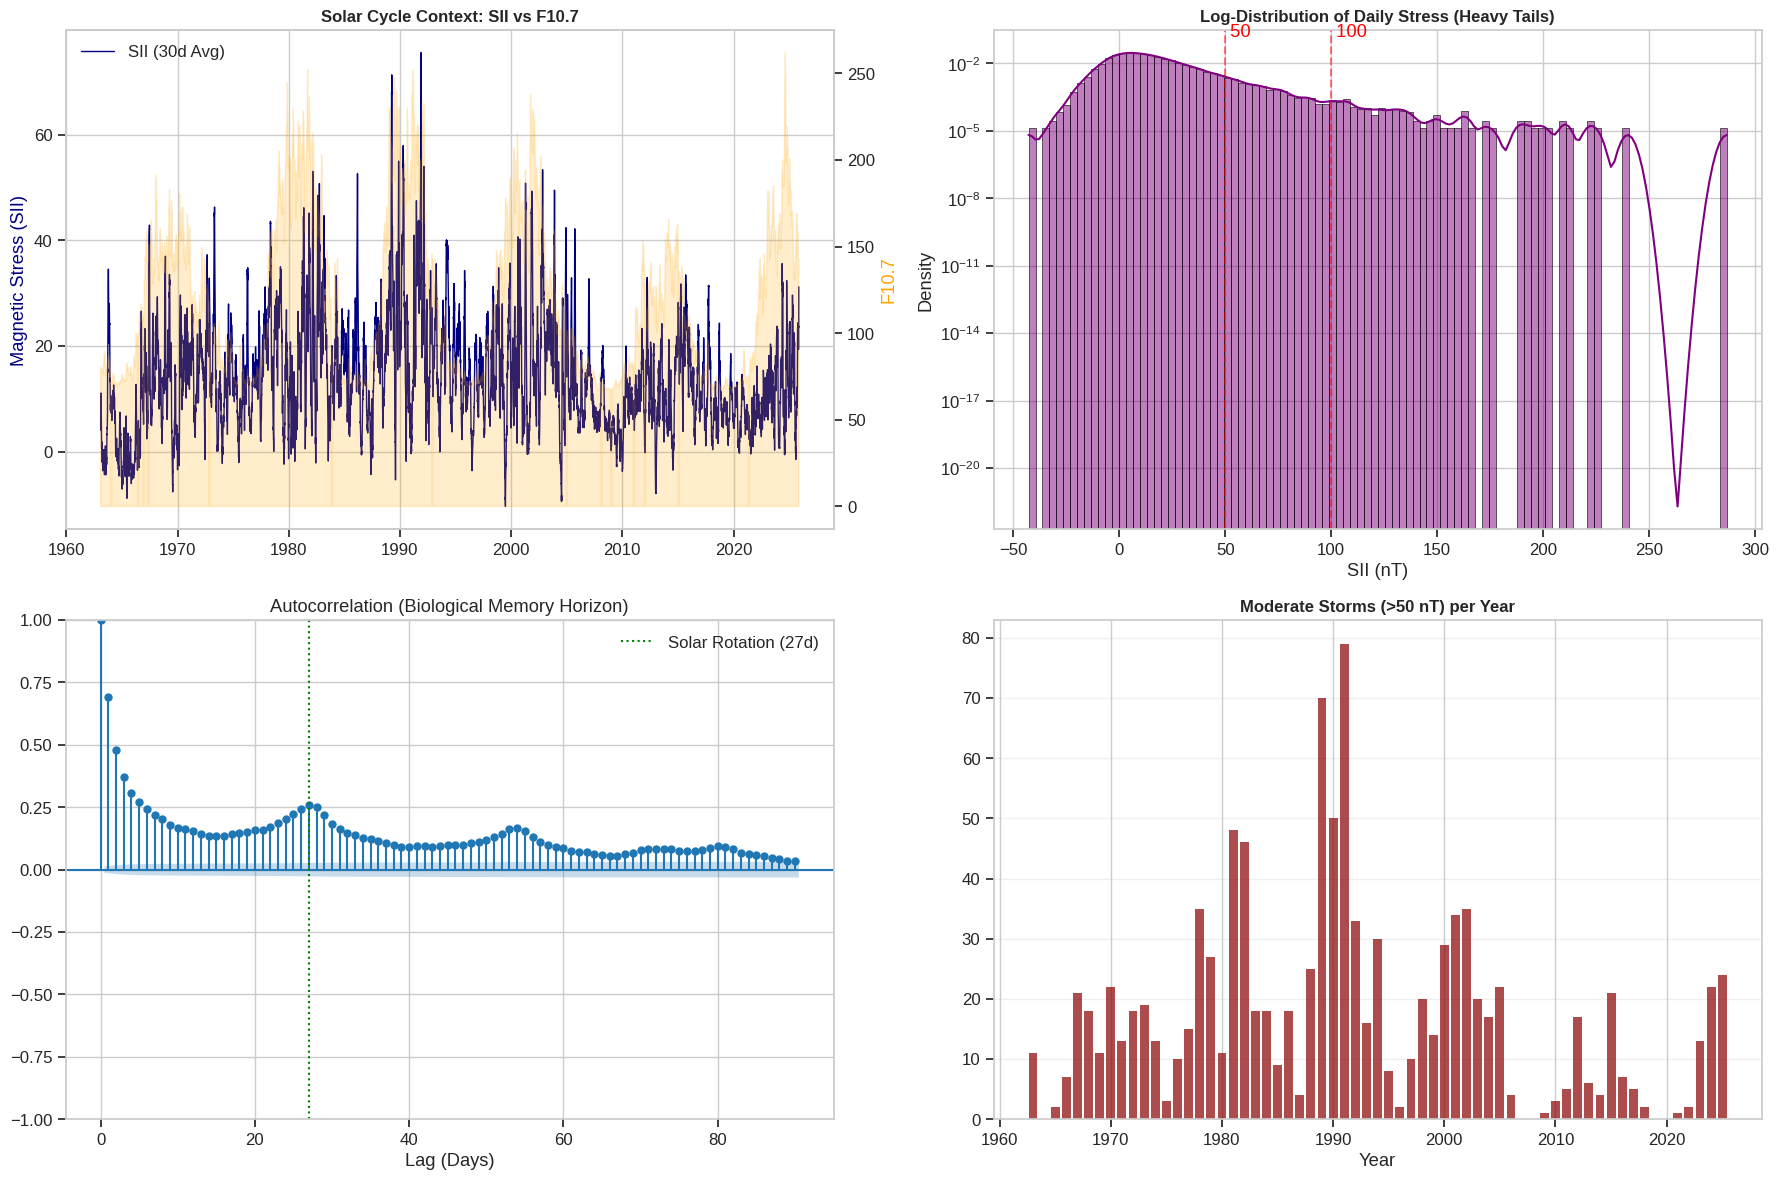

In [4]:
"""
QA Notebook: Space Weather (OMNI2)
Focus: SII/Dst Dynamics, Solar Cycle Phases, and Lag Correlations.
"""

import sys
import os
from pathlib import Path

# /project_root
#   /analysis  --  jupyter
#   /scripts   --  _Common.py

current_dir = Path.cwd()
scripts_dir = current_dir.parent / 'scripts'

if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from _Common import Config, RegionFlag

# %load_ext autoreload
# %autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
from scipy import stats
import pyarrow.feather as feather

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

def run_comprehensive_analysis():
    print(f"Loading OMNI data from: {Config.FILE_OMNI_FEATHER}")
    df = feather.read_feather(Config.FILE_OMNI_FEATHER)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    
    # Select the main variable for analysis
    # We use 'sii_mean' (daily mean stress) or 'sii_max' (peak stress)
    # Let's analyze SII_MEAN as it represents the "Dose"
    target_col = 'sii_mean'
    series = df[target_col].dropna()
    
    print(f"\n{'='*70}")
    print(f"DEEP STATISTICAL ANALYSIS: {target_col.upper()}")
    print(f"Period: {series.index.min().date()} to {series.index.max().date()}")
    print(f"N Observations: {len(series):,}")
    print(f"{'='*70}")

    # =========================================================================
    # 1. DISTRIBUTION & NORMALITY
    # =========================================================================
    print(f"\n{'─'*50}")
    print("1. DISTRIBUTION & NORMALITY TESTS")
    print(f"{'─'*50}")
    
    desc = series.describe()
    skew = series.skew()
    kurt = series.kurtosis()
    
    print(f"Mean:   {desc['mean']:.2f} nT")
    print(f"Median: {desc['50%']:.2f} nT")
    print(f"Std:    {desc['std']:.2f} nT")
    print(f"Max:    {desc['max']:.2f} nT")
    print(f"Skewness: {skew:.3f} (expect > 0 for SII)")
    print(f"Kurtosis: {kurt:.3f} (expect high for heavy tails)")
    
    # Normality Test (D'Agostino's K^2 test)
    k2, p_norm = stats.normaltest(series)
    print(f"\nNormality Test (D'Agostino-Pearson):")
    print(f"  p-value: {p_norm:.2e}")
    if p_norm < 0.05:
        print("  RESULT: REJECT Null Hypothesis. Data is NOT Normal.")
        print("  -> Justification for using Non-Parametric Correlation (Spearman).")
    else:
        print("  RESULT: Data looks Normal.")

    # =========================================================================
    # 2. STATIONARITY (ADF Test)
    # =========================================================================
    print(f"\n{'─'*50}")
    print("2. STATIONARITY (Augmented Dickey-Fuller)")
    print(f"{'─'*50}")
    
    try:
        # Use a reasonable lag based on data frequency
        adf_res = adfuller(series, maxlag=60, autolag='AIC')
        print(f"ADF Statistic: {adf_res[0]:.4f}")
        print(f"p-value: {adf_res[1]:.4e}")
        print("Critical Values:")
        for key, value in adf_res[4].items():
            print(f"  {key}: {value:.4f}")
            
        if adf_res[1] < 0.05:
            print("\n  RESULT: Series is STATIONARY (No unit root).")
            print("  -> Suitable for direct correlation analysis without differencing.")
        else:
            print("\n  RESULT: Series is NON-STATIONARY.")
    except Exception as e:
        print(f"ADF Test Failed: {e}")

    # =========================================================================
    # 3. PHYSICAL STORM ANALYSIS
    # =========================================================================
    print(f"\n{'─'*50}")
    print("3. STORM CLASSIFICATION (SII = -Dst)")
    print(f"{'─'*50}")
    
    # SII is Positive. Dst is Negative. 
    # SII > 30 corresponds to Dst < -30
    thresholds = {
        'Weak (> 30 nT)': 30,
        'Moderate (> 50 nT)': 50,
        'Strong (> 100 nT)': 100,
        'Severe (> 200 nT)': 200,
        'Extreme (> 300 nT)': 300
    }
    
    total_days = len(series)
    for label, thresh in thresholds.items():
        count = (series > thresh).sum()
        pct = (count / total_days) * 100
        print(f"{label:<20}: {count:>4} days ({pct:.2f}%)")
        
    # Top 5 Storms
    print(f"\nTop 5 Most Intense Days:")
    top5 = series.nlargest(5)
    for date, val in top5.items():
        print(f"  {date.date()}: {val:.1f} nT")

    # =========================================================================
    # 4. VISUALIZATION DASHBOARD
    # =========================================================================
    fig = plt.figure(figsize=(18, 12))
    
    # Plot 1: Solar Cycle Context
    ax1 = plt.subplot(2, 2, 1)
    # Need F10.7 for context
    if 'f10_7_mean_ma30' in df.columns:
        ax1_r = ax1.twinx()
        ax1_r.fill_between(df.index, df['f10_7_mean_ma30'], color='orange', alpha=0.2, label='F10.7 (Solar Cycle)')
        ax1_r.set_ylabel('F10.7', color='orange')
        ax1_r.grid(False)
    
    ax1.plot(df.index, df['sii_mean_ma30'], color='navy', lw=1, label='SII (30d Avg)')
    ax1.set_title('Solar Cycle Context: SII vs F10.7', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Magnetic Stress (SII)', color='navy')
    ax1.legend(loc='upper left')

    # Plot 2: Histogram & Distribution
    ax2 = plt.subplot(2, 2, 2)
    sns.histplot(series, bins=100, kde=True, color='purple', ax=ax2, stat='density')
    ax2.set_yscale('log') # Log scale because tails are heavy
    ax2.set_title('Log-Distribution of Daily Stress (Heavy Tails)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('SII (nT)')
    # Add thresholds
    for thr in [50, 100]:
        ax2.axvline(thr, color='red', ls='--', alpha=0.5)
        ax2.text(thr, ax2.get_ylim()[1]*0.5, f' {thr}', color='red')

    # Plot 3: Autocorrelation (Memory)
    ax3 = plt.subplot(2, 2, 3)
    plot_acf(series, lags=90, ax=ax3, alpha=0.05, title='Autocorrelation (Biological Memory Horizon)')
    ax3.set_xlabel('Lag (Days)')
    ax3.axvline(27, color='green', ls=':', label='Solar Rotation (27d)')
    ax3.legend()

    # Plot 4: Annual Storm Count
    ax4 = plt.subplot(2, 2, 4)
    # Count storms > 50 nT per year
    storm_mask = series > 50
    annual_counts = series[storm_mask].groupby(series[storm_mask].index.year).count()
    ax4.bar(annual_counts.index, annual_counts.values, color='darkred', alpha=0.7)
    ax4.set_title('Moderate Storms (>50 nT) per Year', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Year')
    ax4.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_comprehensive_analysis()